In [1]:
from Autograd import Tensor
from Activation import ReLU
from Loss import cross_entropy_loss
from Model import Linear,Sequential,Layernorm,Embedding,Flatten,Module
from Optimiser import SGD,Momentum,Adagrad,RMSProp,Adadelta,Adam
from Training import training
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class MultiHeadAttention(Module):
    def __init__(self,embedding_dim,no_heads,block_size):
        self.embedding_dim=embedding_dim
        self.no_heads=no_heads
        self.block_size=block_size
        self.head_dim=embedding_dim//no_heads

        self.mask=np.triu(np.ones((block_size,block_size)),k=1)

        self.Wv=Tensor(np.random.rand(embedding_dim,self.head_dim*no_heads)*np.sqrt(1/(embedding_dim)),requires_grad=True)
        self.Wk=Tensor(np.random.rand(embedding_dim,self.head_dim*no_heads)*np.sqrt(1/(embedding_dim)),requires_grad=True)
        self.Wq=Tensor(np.random.rand(embedding_dim,self.head_dim*no_heads)*np.sqrt(1/(embedding_dim)),requires_grad=True)

        self.Wo=Tensor(np.random.rand(embedding_dim,self.head_dim*no_heads)*np.sqrt(1/(embedding_dim)),requires_grad=True)

    def forward(self,x):
        B,T,E=x.shape

        query=x@self.Wq
        key=x@self.Wk
        value=x@self.Wv

        split_query=query.reshape((B,T,self.no_heads,self.head_dim)).transpose(1,2)
        split_key=key.reshape((B,T,self.no_heads,self.head_dim)).transpose(1,2)
        split_value=value.reshape((B,T,self.no_heads,self.head_dim)).transpose(1,2)

        scores=split_query@split_key.transpose()/np.sqrt(self.head_dim)+Tensor(np.where(self.mask[:T,:T],-np.inf,0))
        softmax_scores=scores.softmax()@split_value
        recombined_scores=softmax_scores.transpose(1,2).reshape((B,T,E))

        return recombined_scores@self.Wo

In [3]:
def data_read(prop):
    df=pd.read_csv("names.txt",header=None)
    data_list=df[0].tolist()
    random.shuffle(data_list)
    chars=sorted(set("".join(data_list)))
    chars.append(".")
    encodedict={}
    decodedict={}
    for id,char in enumerate(chars):
        encodedict[char]=id
        decodedict[id]=char
    length=len(data_list)
    n=int(length*prop)
    train_set=data_list[:n]
    test_set=data_list[n:]
    return train_set,test_set,encodedict,decodedict

def encode(name):
    return [encodedict[ch] for ch in name]
def decode(sequence):
    return "".join([decodedict[id] for id in sequence])

def tokeniser(data,block_size):
    tokens=encode(".".join(data))
    X=[]
    Y=[]
    for i in range(len(tokens)-block_size):
        X.append(tokens[i:i+block_size])
        Y.append(tokens[i+1:i+block_size+1])
    return X,Y

In [36]:
block_size=5

train_set,test_set,encodedict,decodedict=data_read(0.5)
X,Y=tokeniser(train_set,block_size)
X,Y=Tensor(X),Tensor(Y)
no_characters=len(encodedict)

In [37]:
embedding_dim=32

no_heads=8

hidden_dim=128

In [38]:
class FFN(Module):
    def __init__(self,input_dim,output_dim,hidden_dim=128):
        self.ffn=Sequential([Linear(input_dim,hidden_dim),ReLU(),Linear(hidden_dim,output_dim)])
    def forward(self,x):
        return self.ffn.forward_prop(x)

In [39]:
class Transformer(Module):
    def __init__(self,embedding_dim,no_heads,vocab_size,block_size,hidden_dim):
        self.block_size=block_size
        self.head_dim=embedding_dim//no_heads
        self.no_heads=no_heads
        self.token_embedding=Embedding(vocab_size,embedding_dim)
        self.position_embedding=Embedding(block_size,embedding_dim)
        self.attention=MultiHeadAttention(embedding_dim,no_heads,block_size)
        self.layernorm1=Layernorm(embedding_dim)
        self.ff=FFN(embedding_dim,embedding_dim,hidden_dim)
        self.layernorm2=Layernorm(embedding_dim)
        self.linear2=Linear(embedding_dim,vocab_size)
    def forward_prop(self,x):
        B,T=x.shape
        embedding_out=self.token_embedding.forward(x)+self.position_embedding.forward(Tensor(np.arange(T),requires_grad=False))
        attention_scores=self.attention.forward(embedding_out)
        layernormed=self.layernorm1.forward(embedding_out+attention_scores)
        ffn=self.ff.forward(layernormed)
        layernormed2=self.layernorm2.forward(layernormed+ffn)
        linear_classification=self.linear2.forward(layernormed2)
        return linear_classification

In [ ]:
model=Transformer(embedding_dim,no_heads,no_characters,block_size,hidden_dim)
loss_fn=cross_entropy_loss
optimiser=Adam(model.parameters())
loss=training(X,model,Y,loss_fn,500,optimiser,64)

np.float64(2.0010224947824926)

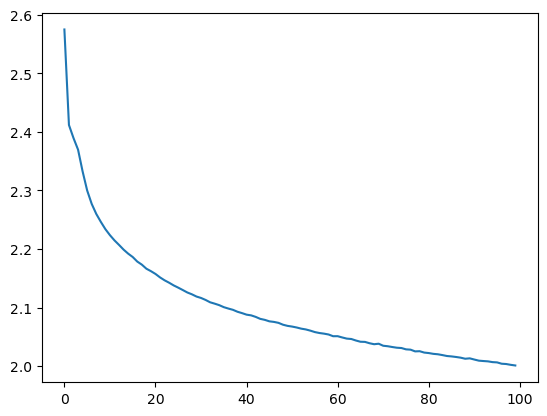

In [29]:
plt.plot(loss)
loss[-1]

In [31]:
start_name=".rik"
if len(start_name)>block_size:
    start_name=start_name[-block_size:]
iterations=1000
trials=[]
for i in range(iterations):
    name=start_name
    characters=[ch for ch in name]
    letter=name[-1]
    while letter!=".":
        tokenised=encode(name)
        logits=model.forward_prop(Tensor([tokenised]))[0,-1]
        probs=logits.softmax()
        next_id=np.random.choice(no_characters,p=probs.data)
        letter=decodedict[next_id]
        characters.append(letter)
        name=name[1:]+letter
    final_name="".join(characters)
    trials.append(final_name[1:-1])

name=start_name
characters=[ch for ch in name]
letter=name[-1]
while letter!=".":
    tokenised=encode(name)
    logits=model.forward_prop(Tensor([tokenised]))[0,-1]
    probs=logits.softmax()
    next_id=np.argmax(probs.data)
    letter=decodedict[next_id]
    characters.append(letter)
    name=name[1:]+letter
greedy_name="".join(characters)
print(greedy_name[1:-1])

from collections import Counter

counts=Counter(trials)
df=pd.DataFrame(counts.items(),columns=["Names","Counter"]).sort_values(by="Counter",ascending=False)
df.head(10)

rika


,Names,Counter
1,rika,491
11,riki,53
3,rikia,33
8,riko,23
15,riking,17
5,rikin,17
27,rikah,17
18,rikai,13
33,rikie,12
82,rike,10
